# Diverse Circuit Routing in Multi-Layer Optical Networks
[![diverse_routing.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/lentz/telecom/diverse_routing.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/lentz/telecom/diverse_routing.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/lentz/telecom/diverse_routing.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/lentz/telecom/diverse_routing.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/lentz/telecom/diverse_routing.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/lentz/telecom/diverse_routing.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/lentz/telecom/diverse_routing.ipynb)](https://ampl.com)

Description: SRLG-diverse routing of circuits over a heterogeneous multi-layer DWDM network with express and multiplex links, node inclusion/exclusion and maximally diverse routing, following Xu et al. (2013)

Tags: telecom, network-design, diverse-routing, srlg, multi-objective, mip, amplpy, highs

Notebook author: Jürgen Lentz <<lentz@ampl.com>>

Model author: Dahai Xu, Guangzhi Li, Byrav Ramamurthy, Angela Chiu, Dongmei Wang, Robert Doverspike

References:
* D. Xu, G. Li, B. Ramamurthy, A. Chiu, D. Wang, R. Doverspike. *On provisioning diverse circuits in heterogeneous multi-layer optical networks*. Computer Communications 36 (2013) 689–697. https://doi.org/10.1016/j.comcom.2012.08.014

Large carriers are often asked to provision several **physically diverse** high-speed circuits, for example two circuits between the same pair of offices that must not fail together. Their core optical network has several layers (fiber spans, DWDM/ROADM links, express links, multiplex links, circuits), and its DWDM systems come from different vendors. A single cut of a fiber span can bring down every DWDM link routed over it; such a span is a **Shared Risk Link Group (SRLG)**.

Xu et al. solve this in two steps:

1. An **integer linear program (ILP)**, written in AMPL, finds absolutely or maximally SRLG-diverse routes with minimum cost or distance.
2. A post-processing step on an auxiliary graph selects DWDM systems, places regenerators and assigns wavelengths along the fixed routes.

This notebook implements the ILP of step 1 with `amplpy` on the example network of Fig. 3 of the paper. We will:
- build the *extended graph* of DWDM, express and multiplex links and derive its risk groups,
- route circuits that are absolutely SRLG- and node-diverse, minimizing cost or distance,
- force a route through some offices and keep it away from others,
- switch to **maximally** diverse routing when no fully diverse solution exists, and look at the trade-off controlled by the weight $W$.

In [1]:
# Install dependencies
%pip install -q amplpy pandas matplotlib

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["highs", "gurobi"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

The paper solved the ILP with Gurobi. The instances in this notebook are small, so the open-source solver HiGHS is enough; set `SOLVER = "gurobi"` to use Gurobi instead.

In [3]:
SOLVER = "highs"  # or "gurobi"

## Background: the components of a core optical network

This section explains the network parts the model works with, from the physical fiber up to the circuits a customer orders. It follows Sections 1 and 2 of the paper.

### Layers

The paper splits the network into five layers (Fig. 2 of the paper). Each layer is carried by the one below it:

| Layer | What it contains | Carried over |
|---|---|---|
| 1. Circuit layer | the customer's end-to-end circuits, e.g. 2.5 or 10 Gbps | multiplex or express links |
| 2. Multiplex-link layer | channelized wavelengths that carry several lower-rate circuits | express links |
| 3. Express-link layer | lightpaths that cross several DWDM links without regeneration | DWDM links |
| 4. DWDM (ROADM) link layer | links between two DWDM nodes of the same system | fiber spans |
| 5. Fiber-span layer | the physical fiber in cables, conduits and on poles | — |

A failure in a lower layer hits everything above it. Diverse routing has to look through all the layers down to the fiber.

### Fiber spans and shared risk link groups (SRLGs)

Fibers run inside cables, laid in ducts and concrete conduits or hung on poles (*aerial* fiber). Fibers are spliced or patched together at *fiber junctions*. The fiber between two neighboring junctions is a **fiber span**.

A DWDM link usually runs over several fiber spans, and a span usually carries several DWDM links. A single cut, for example from a backhoe, therefore takes down **all** DWDM links over that span. The set of links that fail together is a **shared risk link group (SRLG)**. Two circuits are *physically diverse* only if they share no fiber span, no junction, and no other optical facility. For the model this means sharing no SRLG.

### DWDM systems

**Dense Wavelength Division Multiplexing (DWDM)** sends many signals over one fiber, each on its own wavelength (a *channel* of the optical grid). A point-to-point DWDM system has a terminal at each end, connected by a pair of fibers (one per direction):

```
client       optical                                            optical         client
signal       transponder                                        transponder     signal
router --λ0--> [OT] --λ1--+                               +--λ1--> [OT] --λ0--> router
router --λ0--> [OT] --λ2--+-- MUX ==== fiber ==== DEMUX --+--λ2--> [OT] --λ0--> router
router --λ0--> [OT] --λn--+      (inline amplifiers)      +--λn--> [OT] --λ0--> router
```

- The **client signal**, typically from a large IP router, leaves the router on a common short-reach wavelength λ0.
- An **optical transponder (OT)** converts it to one DWDM wavelength λk and back again at the far end.
- The **multiplexer** combines the n wavelengths onto one fiber, and the **demultiplexer** separates them at the other terminal.
- **Amplifiers** along the fiber boost the signal. Their number depends on the length and quality of the fiber.

In the model, a **DWDM node** is an office with DWDM equipment and a **DWDM link** is one point-to-point section of a DWDM system.

### Heterogeneous systems: OADM and ROADM

A carrier's network contains systems from different vendors and technology generations. They differ in the rates they support, in cost and in optical reach:

- **Point-to-point DWDM** (Type 1 in the example) connects exactly two terminals.
- **OADM** (optical add/drop multiplexer, Type 2) can add or drop a few fixed wavelengths at intermediate offices of a chain.
- **ROADM** (reconfigurable OADM, Type 3) nodes have several degrees and form a mesh. At each node, every wavelength can be added, dropped, regenerated or passed through, and this can be reconfigured remotely.

Systems of the same type form their own sub-network. A circuit can only change systems at an office where both are present, and that costs equipment.

### Optical reach, regenerators and express links

An optical signal degrades with distance. The distance it can travel without being converted Optical-to-Electronic-to-Optical (**OEO**) is its **optical reach**; modern ROADM systems reach 1500 km or more. A **regenerator** performs the OEO conversion. It is needed when a circuit is longer than the optical reach or has to change wavelength.

- Inside **one** system, a single regenerator connects two DWDM links.
- **Between two different** systems, the circuit has to go down to λ0 and back up. That takes two back-to-back OTs, which usually cost more than one regenerator.

An optical path that crosses several DWDM links without regeneration is a **lightpath**, called an **express link** in the paper. For example, a Type 2 signal can travel from `I` through `B` to `D` without stopping. Express links save regenerators, so they are cheaper than the chain of DWDM links underneath them. They are still exposed to every SRLG of those links.

### Multiplexing and multiplex links

Many ROADM channels run at 10 or 40 Gbps, while many circuits are still ordered at lower rates such as 2.5 Gbps. Several low-rate signals can be multiplexed into one high-rate channel: four 2.5 Gbps signals in a 10 Gbps channel, or four 10 Gbps signals in a 40 Gbps channel. Each low-rate signal uses a **sub-channel**. A signal that carries sub-channels is *channelized*.

A channelized lightpath is a **multiplex link**. If an existing multiplex link still has unused sub-channels, its multiplexing transponders are already installed. A new low-rate circuit can then use one at almost no extra capital cost, which is why the routing should prefer them.

### Circuits and their requirements

A **circuit** is a point-to-point connection ordered by a customer, for example one leg of an optical VPN. A planner receives several circuits at once, each with:
- a source and a destination office and a rate,
- offices the route must **include** or **avoid**,
- the requirement that all circuits be mutually **SRLG-diverse** and, optionally, **node-diverse** (no office shared as a transit point).

### Cost

The capital cost of a circuit has two parts:
- the **common cost**: the circuit's share of the DWDM system, amplifiers and fiber. It is modeled as a unit cost per wavelength-mile times the length. Different systems have different unit costs.
- the **terminal cost**: optical transponders at both ends of each DWDM segment and regenerators in between.

In this notebook, the cost of using an edge for a given rate is a fixed channel cost plus a per-mile common cost, both taken from the `price` table.

### From network components to model entities

The ILP works on an **extended graph**. Its nodes are the offices; its edges are all links a circuit can be routed on, whether DWDM, express or multiplex. Express and multiplex links are called *bypassing edges* because they bypass intermediate offices. Every component above becomes a set or parameter of the AMPL model:

| Network component | Python data | AMPL entity |
|---|---|---|
| Office (DWDM node) | `pos` | `NODES` |
| DWDM link, express link, multiplex link | `dwdm`, `bypass` → `links` | `EDGES` with end offices `a`, `b` |
| Offices an edge passes without terminating | `links.passes` | `PASS{EDGES}` |
| Length of an edge | `links.miles` | `dist` |
| System type and spare capacity: can the edge carry a rate? | `links["cost …G"]` not missing | `ok{EDGES, RATES}` |
| Channel cost (OT/regenerator + common cost) | `price` → `links["cost …G"]` | `cost{EDGES, RATES}` |
| Fiber-span SRLG and DWDM link shared by bypassing edges | `srlgs`, `risk` | `FG`, `FE{FG}`, fiber mileage `C` |
| Circuit demand | dictionaries passed to `solve_routes` | `DEMANDS`, `S`, `D`, `rate`, `INCLUDE`, `AVOID` |

The decision variables then describe a routing on this graph. `x` chooses the edges of each route, `y` records which risk groups a route uses, and `z` labels nodes to rule out loops. The penalties `YG` and `YV` measure how much diversity is given up when absolute diversity is impossible.

## The example network

The network of Fig. 3 in the paper has 9 offices `A`–`I` and 14 DWDM links built from three vendor systems:

| System | Kind | Links | Rates |
|---|---|---|---|
| Type 1 | point-to-point DWDM | A-B, B-C, A-I | 2.5 Gbps |
| Type 2 | OADM | C-D-H, I-B-D | 2.5 and 10 Gbps |
| Type 3 | ROADM | A-C-E-F-G-H-I, E-H | 10 Gbps (2.5 Gbps by channelizing a wavelength) |

Two details matter for diverse routing:
- **Node passing**: the ROADM link `A-C` is laid along the same fiber as `A-B` and `B-C`, so it physically passes office `B`.
- **SRLGs**: `srlg1` (A-B, A-C), `srlg2` (B-C, A-C) and `srlg3` (E-H, G-H) are fiber spans shared by several DWDM links.

On top of the DWDM links there are **bypassing edges**:
- *Express links* are lightpaths that pass an office without regeneration. For example, a 10 Gbps signal can travel optically from `I` to `D` through `B`. There are two parallel express links from `C` to `H`, one through `D` (Type 2) and one through `E` (Type 3).
- *Multiplex links* are existing channelized 10 Gbps wavelengths with unused 2.5 Gbps sub-channels. Their transponders are already installed, so they are almost free for a new 2.5 Gbps circuit.

Office coordinates are only used for drawing and to derive link lengths in miles. Each link's cost for a rate is a fixed channel cost (transponders or regenerators) plus a common cost per mile.

In [4]:
import math
import pandas as pd

# office coordinates (for drawing and link lengths)
pos = {
    "A": (1.0, 4.0),
    "B": (3.0, 3.4),
    "C": (5.0, 4.3),
    "D": (4.8, 2.6),
    "E": (8.0, 3.2),
    "F": (10.0, 0.5),
    "G": (7.6, 0.5),
    "H": (5.4, 0.5),
    "I": (1.0, 1.9),
}

# DWDM links: name -> (system, offices along its fiber route)
dwdm = {
    "A-B": ("Type 1", "AB"),
    "B-C": ("Type 1", "BC"),
    "A-I": ("Type 1", "AI"),
    "C-D": ("Type 2", "CD"),
    "D-H": ("Type 2", "DH"),
    "I-B": ("Type 2", "IB"),
    "B-D": ("Type 2", "BD"),
    "A-C": ("Type 3", "ABC"),  # passes office B
    "C-E": ("Type 3", "CE"),
    "E-F": ("Type 3", "EF"),
    "F-G": ("Type 3", "FG"),
    "G-H": ("Type 3", "GH"),
    "H-I": ("Type 3", "HI"),
    "E-H": ("Type 3", "EH"),
}

# bypassing edges: name -> (kind, system, offices along its route, DWDM links used)
bypass = {
    "I-D (exp)": ("express", "Type 2", "IBD", ["I-B", "B-D"]),
    "C-H (exp, via D)": ("express", "Type 2", "CDH", ["C-D", "D-H"]),
    "C-H (exp, via E)": ("express", "Type 3", "CEH", ["C-E", "E-H"]),
    "A-E (exp)": ("express", "Type 3", "ABCE", ["A-C", "C-E"]),
    "C-F (exp)": ("express", "Type 3", "CEF", ["C-E", "E-F"]),
    "I-F (mux)": ("multiplex", "Type 3", "IHGF", ["H-I", "G-H", "F-G"]),
    "H-F (mux)": ("multiplex", "Type 3", "HGF", ["G-H", "F-G"]),
}

# fiber-span SRLGs: name -> (DWDM links routed over the span, span length in miles)
srlgs = {
    "srlg1": ({"A-B", "A-C"}, 25),
    "srlg2": ({"B-C", "A-C"}, 20),
    "srlg3": ({"E-H", "G-H"}, 30),
}

RATES = [2.5, 10]

# (system, rate) -> (fixed cost per channel, common cost per mile)
price = {
    ("Type 1", 2.5): (10, 0.05),
    ("Type 2", 2.5): (12, 0.04),
    ("Type 2", 10): (30, 0.08),
    ("Type 3", 2.5): (30, 0.03),  # a full wavelength plus a muxponder
    ("Type 3", 10): (25, 0.03),
    ("Multiplex", 2.5): (0, 0.005),  # unused sub-channel, transponders installed
}

From these data we build the table of all edges of the extended graph: their end offices, the offices they pass through, their length, and their cost per rate. A missing cost means the edge cannot carry that rate. In the paper, links without enough capacity are dropped in the same way before the ILP is built.

In [5]:
def miles(u, v):
    (x1, y1), (x2, y2) = pos[u], pos[v]
    return round(100 * math.hypot(x2 - x1, y2 - y1))


rows = []
for name, (system, route) in dwdm.items():
    rows.append(
        dict(link=name, kind="DWDM", system=system, route=list(route), base=[name])
    )
for name, (kind, system, route, base) in bypass.items():
    rows.append(dict(link=name, kind=kind, system=system, route=list(route), base=base))

links = pd.DataFrame(rows).set_index("link")
links["a"] = links.route.str[0]
links["b"] = links.route.str[-1]
links["passes"] = links.route.str[1:-1]
links["miles"] = links.route.apply(lambda r: sum(miles(u, v) for u, v in zip(r, r[1:])))


def channel_cost(row, rate):
    key = ("Multiplex" if row.kind == "multiplex" else row.system, rate)
    if key not in price:
        return None
    fixed, per_mile = price[key]
    return round(fixed + per_mile * row.miles, 1)


for r in RATES:
    links[f"cost {r}G"] = links.apply(channel_cost, axis=1, rate=r)

links[["kind", "system", "a", "b", "passes", "miles", "cost 2.5G", "cost 10G"]]

,kind,system,a,b,passes,miles,cost 2.5G,cost 10G
link,,,,,,,,
A-B,DWDM,Type 1,A,B,[],209,20.5,NaN
B-C,DWDM,Type 1,B,C,[],219,21.0,NaN
A-I,DWDM,Type 1,A,I,[],210,20.5,NaN
C-D,DWDM,Type 2,C,D,[],171,18.8,43.7
D-H,DWDM,Type 2,D,H,[],218,20.7,47.4
I-B,DWDM,Type 2,I,B,[],250,22.0,50.0
B-D,DWDM,Type 2,B,D,[],197,19.9,45.8
A-C,DWDM,Type 3,A,C,[B],428,42.8,37.8
C-E,DWDM,Type 3,C,E,[],320,39.6,34.6


### Risk groups

Two routes are diverse if they share no risk group. The paper uses two kinds of groups:

- **Basic SRLGs** $G$: fiber spans. Group $g$ fails every edge $FE[g]$ that uses one of its DWDM links, including express and multiplex links routed over them.
- **Extended SRLGs** $XG$: a DWDM link acts as a virtual fiber span for all express and multiplex links that ride on it. For example, `I-B` fails together with the express link `I-D (exp)`.

To keep the ILP small, groups whose edge set is contained in another group's edge set are dropped. They add no constraint in absolutely diverse routing. For instance, the DWDM link `A-B` is already covered by `srlg1`.

In [6]:
groups = {}
for g, (members, span_miles) in srlgs.items():
    groups[g] = ({e for e in links.index if set(links.base[e]) & members}, span_miles)
for d in dwdm:
    groups[d] = ({e for e in links.index if d in links.base[e]}, links.miles[d])

# keep only groups that are not contained in another group (ties: keep the first)
names = list(groups)
risk = {
    g: groups[g]
    for i, g in enumerate(names)
    if not any(
        groups[g][0] < groups[h][0] or (groups[g][0] == groups[h][0] and j < i)
        for j, h in enumerate(names)
        if h != g
    )
}
print(f"{len(groups)} risk groups, {len(risk)} after reduction\n")
for g, (fe, span_miles) in risk.items():
    print(f"{g:6} {span_miles:4} mi  {sorted(fe)}")

17 risk groups, 12 after reduction

srlg1    25 mi  ['A-B', 'A-C', 'A-E (exp)']
srlg2    20 mi  ['A-C', 'A-E (exp)', 'B-C']
srlg3    30 mi  ['C-H (exp, via E)', 'E-H', 'G-H', 'H-F (mux)', 'I-F (mux)']
A-I     210 mi  ['A-I']
C-D     171 mi  ['C-D', 'C-H (exp, via D)']
D-H     218 mi  ['C-H (exp, via D)', 'D-H']
I-B     250 mi  ['I-B', 'I-D (exp)']
B-D     197 mi  ['B-D', 'I-D (exp)']
C-E     320 mi  ['A-E (exp)', 'C-E', 'C-F (exp)', 'C-H (exp, via E)']
E-F     336 mi  ['C-F (exp)', 'E-F']
F-G     240 mi  ['F-G', 'H-F (mux)', 'I-F (mux)']
H-I     462 mi  ['H-I', 'I-F (mux)']


The next cell defines a helper that draws the network. Line width encodes the system type, as in Fig. 3 of the paper: thin for Type 1, medium for Type 2, thick for Type 3. Routes are drawn on top along the offices they physically traverse.

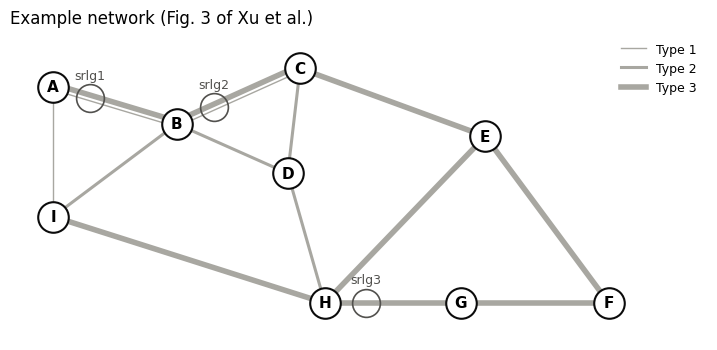

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROUTE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]
WIDTH = {"Type 1": 1.0, "Type 2": 2.2, "Type 3": 4.0}


def offset_segment(u, v, shift):
    (x1, y1), (x2, y2) = pos[u], pos[v]
    length = math.hypot(x2 - x1, y2 - y1)
    nx, ny = -(y2 - y1) / length * shift, (x2 - x1) / length * shift
    return [x1 + nx, x2 + nx], [y1 + ny, y2 + ny]


def draw_network(routes=None, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.8))
    # DWDM links; links sharing a fiber segment are drawn side by side
    on_segment = {}
    for d, (system, route) in dwdm.items():
        for u, v in zip(route, route[1:]):
            on_segment.setdefault(frozenset((u, v)), []).append(d)
    for d, (system, route) in dwdm.items():
        for u, v in zip(route, route[1:]):
            share = on_segment[frozenset((u, v))]
            shift = 0.09 * (share.index(d) - (len(share) - 1) / 2)
            xs, ys = offset_segment(*sorted((u, v)), shift)
            ax.plot(
                xs,
                ys,
                color="#a8a7a1",
                lw=WIDTH[system],
                zorder=1,
                solid_capstyle="round",
            )
    # SRLG markers at the shared fiber segment
    for g, at in {
        "srlg1": ("A", "B"),
        "srlg2": ("B", "C"),
        "srlg3": ("H", "G"),
    }.items():
        (x1, y1), (x2, y2) = pos[at[0]], pos[at[1]]
        x, y = x1 + 0.3 * (x2 - x1), y1 + 0.3 * (y2 - y1)
        ax.plot(x, y, marker="o", ms=20, mfc="none", mec="#52514e", mew=1.2, zorder=2)
        ax.annotate(
            g,
            (x, y),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color="#52514e",
        )
    # routes
    handles = []
    for k, (t, (label, offices)) in enumerate((routes or {}).items()):
        shift = 0.16 * (k - (len(routes) - 1) / 2)
        color = ROUTE_COLORS[k % len(ROUTE_COLORS)]
        for u, v in zip(offices, offices[1:]):
            xs, ys = offset_segment(u, v, shift)
            ax.plot(xs, ys, color=color, lw=3, zorder=3, solid_capstyle="round")
        handles.append(Line2D([], [], color=color, lw=3, label=label))
    # offices
    for u, (x, y) in pos.items():
        ax.plot(x, y, "o", ms=22, mfc="white", mec="#0b0b0b", mew=1.5, zorder=4)
        ax.text(
            x, y, u, ha="center", va="center", fontsize=11, fontweight="bold", zorder=5
        )
    handles += [
        Line2D([], [], color="#a8a7a1", lw=w, label=s) for s, w in WIDTH.items()
    ]
    ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9)
    ax.set_xlim(0.3, 11.6)
    ax.set_ylim(-0.1, 4.9)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left", fontsize=12)
    return ax


draw_network(title="Example network (Fig. 3 of Xu et al.)")
plt.show()

## The ILP model

The paper indexes edges by their end nodes and adds a virtual node for every additional parallel edge. In AMPL it is simpler to give every edge a name: an *arc* $(e,i,j)$ is edge $e$ traversed from $i$ to $j$, and parallel edges such as the two express links `C-H` need no virtual nodes.

**Data.** $S_t$, $D_t$ and $n_t$ are the source, destination and rate of demand $t$; $A_t$ and $I_t$ are the offices route $t$ must avoid or include. $\text{PASS}_e$ is the set of offices that edge $e$ passes through, and $FE_g$ the set of edges of risk group $g$. $EC_u$ counts how often office $u$ is a source or destination of a demand.

**Variables.** $x_{t,e,i,j}\in\{0,1\}$ selects arc $(e,i,j)$ for route $t$; only arcs whose edge can carry rate $n_t$ exist. $y_{t,g}\in\{0,1\}$ is 1 if route $t$ uses group $g$, and $z_{t,u}\in[0,M-1]$ is a node label.

The number of links of route $t$ that touch office $u$ is
$$O_{t,u} = \sum_{(e,i,j):\, u\in\{i,j\}} x_{t,e,i,j} + 2\sum_{(e,i,j):\, u\in \text{PASS}_e} x_{t,e,i,j}.$$
An edge that passes through $u$ counts twice, as if the route entered and left $u$. This is how *implied node inclusion* is handled: a route over `A-C` also occupies `B`.

**Constraints**, numbered as in the paper:

| | Constraint | Meaning |
|---|---|---|
| (1) | $\sum_{(e,u,j)} x_{t,e,u,j} - \sum_{(e,i,u)} x_{t,e,i,u} = [u=S_t] - [u=D_t]$ | flow conservation |
| (2) | $\sum_{(e,i,j):\, e\in FE_g} x_{t,e,i,j} \le 2\,\lvert FE_g\rvert\, y_{t,g}$ | route $t$ uses group $g$ |
| (3) | $\sum_t y_{t,g} \le 1$ | each SRLG is used by at most one route |
| (4) | $\sum_t O_{t,u} = EC_u$ if $EC_u>0$ | end offices are not transit offices of other routes |
| (5) | $\sum_t O_{t,u} \le 2$ if $EC_u=0$ | at most one route passes a transit office |
| (6) | $O_{t,u} = 0,\ u \in A_t$ | avoid offices |
| (7) | $O_{t,u} \ge 1,\ u \in I_t$ | include offices |
| (8) | $z_{t,j} - z_{t,i} \le M(1-x_{t,e,i,j}) - 1$ | no detached loops (needed with node inclusion) |

**Objective** (9): $\Phi = \sum_{t,(e,i,j)} c_{t,e}\, x_{t,e,i,j}$, where $c_{t,e}$ is the channel cost of $e$ for rate $n_t$, its length in miles, or 1 per hop.

**Maximally diverse routing.** When no absolutely diverse routes exist, (3)–(5) are relaxed into penalties: (10) $YG_g \ge C_g(\sum_t y_{t,g} - 1)$, where $C_g$ is the fiber mileage of SRLG $g$, and (11)–(12) $YV_u \ge \sum_t O_{t,u} - EC_u$ (or $-2$ for transit offices). The objective becomes

$$\Phi_m = \Phi + W\Big(\sum_g YG_g + W_N \sum_u YV_u\Big). \tag{13}$$

Following the paper, $W_N = 200$: sharing one office counts as much as sharing 200 miles of fiber.

$O_{t,u}$ is declared as a *defined variable*. AMPL substitutes its expression wherever it appears, so the solver never sees an extra variable. This matters because the paper reports that introducing such auxiliary variables explicitly could make their instances much slower to solve.

In [8]:
%%ampl_eval
# ---------- extended graph ----------
set NODES;                                  # offices
set EDGES;                                  # DWDM, express and multiplex links
set RATES;                                  # circuit rates (Gbps)
param a{EDGES} symbolic in NODES;           # end offices of an edge
param b{EDGES} symbolic in NODES;
set PASS{EDGES} within NODES default {};    # offices an edge passes through
param ok{EDGES, RATES} binary default 0;    # edge has capacity for this rate
param cost{EDGES, RATES} >= 0 default 0;    # cost of a channel of this rate
param dist{EDGES} >= 0;                     # length in miles

set ARCS = setof{e in EDGES} (e, a[e], b[e]) union setof{e in EDGES} (e, b[e], a[e]);

# ---------- risk groups ----------
set FG;                                     # basic and extended SRLGs
set FE{FG} within EDGES;                    # edges failing together
param C{FG} >= 0;                           # fiber mileage of a group

# ---------- demands ----------
set DEMANDS;
param S{DEMANDS} symbolic in NODES;
param D{DEMANDS} symbolic in NODES;
param rate{DEMANDS} in RATES;
set AVOID{DEMANDS} within NODES default {};
set INCLUDE{DEMANDS} within NODES default {};

param EC{u in NODES} = card{t in DEMANDS: S[t] = u} + card{t in DEMANDS: D[t] = u};
param M = card(NODES);                      # max. number of hops + 1

# ---------- settings ----------
param metric symbolic in {"cost", "distance", "hops"} default "cost";
param absolute binary default 1;            # 1: absolutely, 0: maximally diverse
param node_diverse binary default 1;
param W >= 0 default 5000;                  # weight of diversity violation
param WN >= 0 default 200;                  # node violation vs. SRLG violation

param c{t in DEMANDS, e in EDGES} =
    if metric = "cost" then cost[e, rate[t]]
    else if metric = "distance" then dist[e]
    else 1;

set A{t in DEMANDS} = {(e,i,j) in ARCS: ok[e, rate[t]] = 1};

# ---------- variables ----------
var x{t in DEMANDS, (e,i,j) in A[t]} binary;   # route t uses edge e from i to j
var y{DEMANDS, FG} binary;                     # route t uses risk group g
var z{DEMANDS, NODES} >= 0, <= M - 1;          # node labels
var YG{FG} >= 0;                               # SRLG violation
var YV{NODES} >= 0;                            # node violation

# number of links of route t containing office u
var O{t in DEMANDS, u in NODES} =
    sum{(e,i,j) in A[t]: i = u or j = u} x[t,e,i,j]
  + 2 * sum{(e,i,j) in A[t]: u in PASS[e]} x[t,e,i,j];

# ---------- objectives ----------
minimize Phi:                                                   # (9)
    sum{t in DEMANDS, (e,i,j) in A[t]} c[t,e] * x[t,e,i,j];

minimize PhiM:                                                  # (13)
    sum{t in DEMANDS, (e,i,j) in A[t]} c[t,e] * x[t,e,i,j]
  + W * (sum{g in FG} YG[g] + WN * sum{u in NODES} YV[u]);

# ---------- constraints ----------
subject to Flow{t in DEMANDS, u in NODES}:                      # (1)
    sum{(e,u,j) in A[t]} x[t,e,u,j] - sum{(e,i,u) in A[t]} x[t,e,i,u]
    = if u = S[t] then 1 else if u = D[t] then -1 else 0;

subject to SRLGUse{t in DEMANDS, g in FG}:                      # (2)
    sum{(e,i,j) in A[t]: e in FE[g]} x[t,e,i,j] <= 2 * card(FE[g]) * y[t,g];

subject to SRLGDiverse{g in FG: absolute}:                      # (3)
    sum{t in DEMANDS} y[t,g] <= 1;

subject to TerminalNode{u in NODES: absolute and node_diverse and EC[u] > 0}:  # (4)
    sum{t in DEMANDS} O[t,u] = EC[u];

subject to TransitNode{u in NODES: absolute and node_diverse and EC[u] = 0}:   # (5)
    sum{t in DEMANDS} O[t,u] <= 2;

subject to Avoid{t in DEMANDS, u in AVOID[t]}:                  # (6)
    O[t,u] = 0;

subject to Include{t in DEMANDS, u in INCLUDE[t]}:              # (7)
    O[t,u] >= 1;

subject to NoLoop{t in DEMANDS, (e,i,j) in A[t]}:               # (8)
    z[t,j] - z[t,i] <= M * (1 - x[t,e,i,j]) - 1;

subject to SRLGPenalty{g in FG: not absolute}:                  # (10)
    YG[g] >= C[g] * (sum{t in DEMANDS} y[t,g] - 1);

subject to TerminalPenalty{u in NODES: not absolute and node_diverse and EC[u] > 0}:  # (11)
    YV[u] >= sum{t in DEMANDS} O[t,u] - EC[u];

subject to TransitPenalty{u in NODES: not absolute and node_diverse and EC[u] = 0}:   # (12)
    YV[u] >= sum{t in DEMANDS} O[t,u] - 2;

### Loading the network

The network data stay the same for all scenarios, so we send them to AMPL once. Indexed sets such as `PASS` and `FE` are assigned member by member.

In [9]:
ampl.set["NODES"] = list(pos)
ampl.set["RATES"] = RATES
ampl.set["EDGES"] = list(links.index)
ampl.param["a"] = links.a
ampl.param["b"] = links.b
ampl.param["dist"] = links.miles
for e in links.index:
    ampl.set["PASS"][e] = links.passes[e]

usable = [
    (e, r) for e in links.index for r in RATES if pd.notna(links.at[e, f"cost {r}G"])
]
ampl.param["ok"] = {(e, r): 1 for e, r in usable}
ampl.param["cost"] = {(e, r): links.at[e, f"cost {r}G"] for e, r in usable}

ampl.set["FG"] = list(risk)
for g, (fe, _) in risk.items():
    ampl.set["FE"][g] = sorted(fe)
ampl.param["C"] = {g: span_miles for g, (_, span_miles) in risk.items()}

### Solving a set of demands

`solve_routes` loads a set of demands, selects the objective, solves, and rebuilds each route by following its arcs from source to destination. The routes are kept in the same AMPL session; `reset data` clears only the demand data between runs.

`route_table` reports each route: the edges used, the offices it traverses, its cost and length, and a rough equipment count. The count takes the place of the paper's second step: an optical transponder (OT) wherever a circuit enters or leaves a DWDM system, a regenerator where it continues on the same system, and nothing extra on multiplex links, whose transponders are already installed.

In [10]:
def solve_routes(demands, metric="cost", absolute=True, W=5000):
    ampl.eval("reset data DEMANDS, S, D, rate, AVOID, INCLUDE;")
    ampl.set["DEMANDS"] = list(demands)
    ampl.param["S"] = {t: d["S"] for t, d in demands.items()}
    ampl.param["D"] = {t: d["D"] for t, d in demands.items()}
    ampl.param["rate"] = {t: d["rate"] for t, d in demands.items()}
    for t, d in demands.items():
        ampl.set["AVOID"][t] = d.get("avoid", [])
        ampl.set["INCLUDE"][t] = d.get("include", [])
    ampl.param["metric"] = metric
    ampl.param["absolute"] = int(absolute)
    ampl.param["W"] = W
    ampl.eval("objective Phi;" if absolute else "objective PhiM;")

    ampl.solve(solver=SOLVER, verbose=False)
    if ampl.solve_result != "solved":
        return None

    used = [(t, e, i, j) for t, e, i, j, v in ampl.var["x"].to_list() if v > 0.5]
    routes = {}
    for t, d in demands.items():
        nxt = {i: (e, j) for tt, e, i, j in used if tt == t}
        u, path = d["S"], []
        while u != d["D"]:
            e, u = nxt[u]
            path.append(e)
        routes[t] = path
    return routes


def offices(path, source):
    # offices traversed by a route, including those passed by express/multiplex links
    seq = [source]
    for e in path:
        r = links.route[e] if links.route[e][0] == seq[-1] else links.route[e][::-1]
        seq += r[1:]
    return seq


def equipment(path):
    system = [
        ("Multiplex" if links.kind[e] == "multiplex" else links.system[e]) for e in path
    ]
    ots = (system[0] != "Multiplex") + (system[-1] != "Multiplex")
    regens = 0
    for s1, s2 in zip(system, system[1:]):
        if s1 == s2 != "Multiplex":
            regens += 1
        elif s1 != s2:
            ots += (s1 != "Multiplex") + (s2 != "Multiplex")
    return ots, regens


def route_table(demands, routes):
    rows = []
    for t, path in routes.items():
        d = demands[t]
        ots, regens = equipment(path)
        rows.append(
            {
                "demand": t,
                "from-to": f"{d['S']}-{d['D']}",
                "rate": f"{d['rate']}G",
                "edges": ", ".join(path),
                "offices": "-".join(offices(path, d["S"])),
                "cost": round(sum(links.at[e, f"cost {d['rate']}G"] for e in path), 1),
                "miles": sum(links.miles[e] for e in path),
                "OTs": ots,
                "regens": regens,
            }
        )
    return pd.DataFrame(rows).set_index("demand")


def show_routes(demands, routes, title):
    draw_network(
        {
            t: (f"{t}: {d['S']}-{d['D']} {d['rate']}G", offices(routes[t], d["S"]))
            for t, d in demands.items()
        },
        title=title,
    )
    plt.show()

## Scenario 1: two diverse circuits from A to F

This is the example of Section 4 of the paper: a 10 Gbps circuit and a 2.5 Gbps circuit from `A` to `F` must be absolutely SRLG- and node-diverse, at minimum total cost.

In [11]:
demands = {
    "1": dict(S="A", D="F", rate=10),
    "2": dict(S="A", D="F", rate=2.5),
}
routes = solve_routes(demands, metric="cost")
print(f"total cost: {ampl.obj['Phi'].value():.1f}")
route_table(demands, routes)

total cost: 107.6


,from-to,rate,edges,offices,cost,miles,OTs,regens
demand,,,,,,,,
1,A-F,10G,"A-C, C-F (exp)",A-B-C-E-F,82.5,1084,2,1
2,A-F,2.5G,"A-I, I-F (mux)",A-I-H-G-F,25.1,1132,2,0


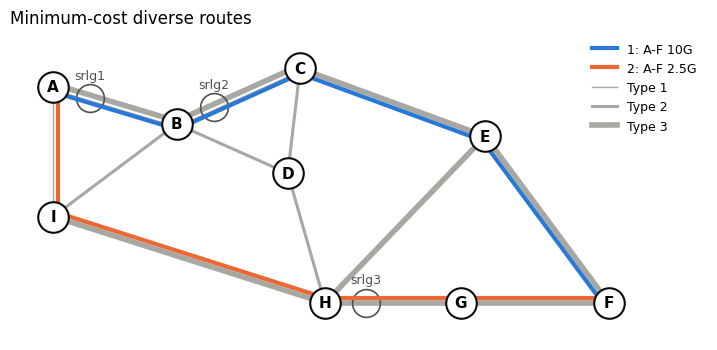

In [12]:
show_routes(demands, routes, "Minimum-cost diverse routes")

The 10 Gbps circuit rides the ROADM system through `C` and `E`, using the express link `C-F` to skip a regeneration at `E`. The 2.5 Gbps circuit leaves `A` on the Type 1 system to `I` and then takes the existing multiplex link `I-F`. The two routes share no office other than their ends and no SRLG. Note that `A-C` physically passes `B`, so `B` is not available to the second route.

The planner may prefer the shortest total distance or the fewest hops instead of the lowest cost. Only the parameter `metric` changes:

In [13]:
for metric in ["cost", "distance", "hops"]:
    routes = solve_routes(demands, metric=metric)
    print(f"{metric:9}", " | ".join("-".join(offices(p, "A")) for p in routes.values()))

cost      A-B-C-E-F | A-I-H-G-F
distance  A-B-C-E-F | A-I-H-G-F
hops      A-B-C-E-F | A-I-H-G-F


On this small network all three metrics choose the same pair of routes. On a large network with legacy and modern systems, they often differ. The paper also reports that minimizing distance is usually much harder for the solver than minimizing cost.

## Scenario 2: including and avoiding offices

Each demand can require offices to be included in or excluded from its route. Node inclusion is where constraint (8) is needed. Without the labels $z$, the solver could return a path from `A` to `F` plus a separate cycle through the required office.

Here a single 10 Gbps circuit from `A` to `F` must pass `D` and avoid `G`.

In [14]:
demands = {"1": dict(S="A", D="F", rate=10, include=["D"], avoid=["G"])}
routes = solve_routes(demands)
print(f"total cost: {ampl.obj['Phi'].value():.1f}")
route_table(demands, routes)

total cost: 170.2


,from-to,rate,edges,offices,cost,miles,OTs,regens
demand,,,,,,,,
1,A-F,10G,"A-C, C-H (exp, via D), E-H, E-F",A-B-C-D-H-E-F,170.2,1528,6,1


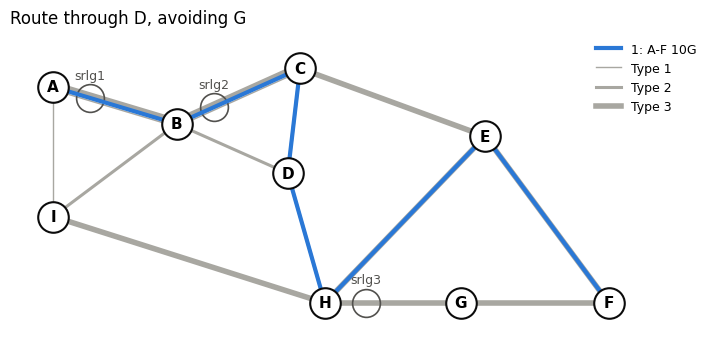

In [15]:
show_routes(demands, routes, "Route through D, avoiding G")

## Scenario 3: when absolute diversity is impossible

A customer asks for three mutually diverse 2.5 Gbps circuits from `A` to `C`. Every edge leaving `A` except `A-I` lies on fiber span `srlg1`, and both `A-B` and `A-C` occupy office `B`. Three absolutely diverse routes cannot exist:

In [16]:
demands = {t: dict(S="A", D="C", rate=2.5) for t in ["1", "2", "3"]}
routes = solve_routes(demands, absolute=True)
print("solve result:", ampl.solve_result)

solve result: infeasible


With `absolute=False`, constraints (3)–(5) are replaced by the penalties (10)–(12) and the solver minimizes $\Phi_m$ from (13). We use $W = 5000$, the value the paper adopted for its planning tool.

In [17]:
def violations():
    srlg = {g: ampl.var["YG"][g].value() for g in risk}
    node = {u: ampl.var["YV"][u].value() for u in pos}
    return {g: v for g, v in srlg.items() if v > 1e-6}, {
        u: v for u, v in node.items() if v > 1e-6
    }


routes = solve_routes(demands, absolute=False, W=5000)
srlg_viol, node_viol = violations()
print(f"cost: {ampl.obj['Phi'].value():.1f}")
print("shared SRLGs (miles):", srlg_viol)
print("shared offices (excess links):", node_viol)
route_table(demands, routes)

cost: 175.5
shared SRLGs (miles): {'srlg1': 25.0}
shared offices (excess links): {'B': 2.0}


,from-to,rate,edges,offices,cost,miles,OTs,regens
demand,,,,,,,,
1,A-C,2.5G,"A-B, B-D, C-D",A-B-D-C,59.2,577,4,1
2,A-C,2.5G,"A-I, I-F (mux), C-F (exp)",A-I-H-G-F-E-C,74.8,1788,4,0
3,A-C,2.5G,"A-B, B-C",A-B-C,41.5,428,2,1


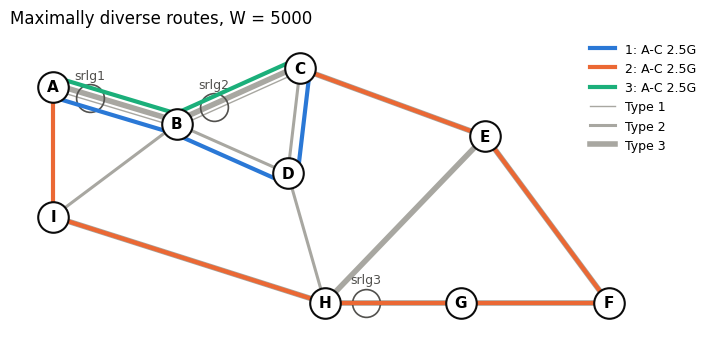

In [18]:
show_routes(demands, routes, "Maximally diverse routes, W = 5000")

Only what cannot be avoided is shared. Routes 1 and 3 both leave `A` on `A-B`, so they share `srlg1` (25 miles of fiber) and office `B`. Route 1 then turns off to `D` to stay clear of `srlg2`. Route 2 escapes over `A-I`, takes the multiplex link `I-F`, and reaches `C` from `F` on the express link through `E`.

### The weight $W$

$W$ sets the price of diversity relative to cost. Section 5.2 of the paper (Fig. 8) shows how the solution moves along the trade-off curve as $W$ grows. We repeat that experiment for the three circuits. The costs in this example are much smaller than in the paper's network, so the range of $W$ starts at 0.01.

In [19]:
rows = []
for W in [0.01, 0.1, 1, 5, 50, 500, 5000]:
    routes = solve_routes(demands, absolute=False, W=W)
    srlg_viol, node_viol = violations()
    rows.append(
        {
            "W": W,
            "cost": round(ampl.obj["Phi"].value(), 1),
            "diversity violation": sum(srlg_viol.values())
            + ampl.param["WN"].value() * sum(node_viol.values()),
            "routes": " | ".join("-".join(offices(p, "A")) for p in routes.values()),
        }
    )
tradeoff = pd.DataFrame(rows).set_index("W")
tradeoff

,cost,diversity violation,routes
W,,,
0.01,124.5,890.0,A-B-C | A-B-C | A-B-C
0.10,157.8,445.0,A-B-C | A-B-C | A-I-H-G-F-E-C
1.00,175.5,425.0,A-B-D-C | A-I-H-G-F-E-C | A-B-C
5.00,175.5,425.0,A-B-D-C | A-B-C | A-I-H-G-F-E-C
50.00,175.5,425.0,A-B-D-C | A-B-C | A-I-H-G-F-E-C
500.00,175.5,425.0,A-B-D-C | A-B-C | A-I-H-G-F-E-C
5000.00,175.5,425.0,A-B-D-C | A-B-C | A-I-H-G-F-E-C


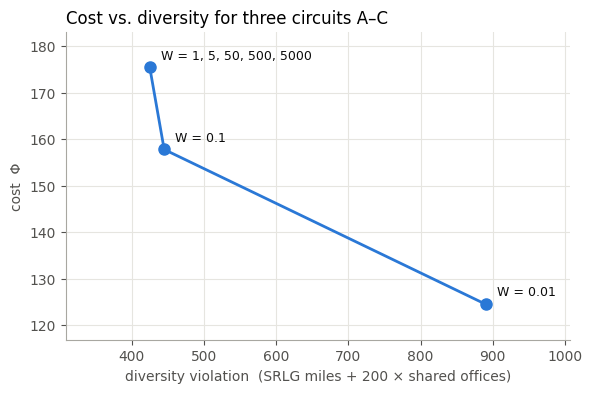

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 4))
points = (
    tradeoff.reset_index()
    .groupby(["diversity violation", "cost"])["W"]
    .apply(list)
    .reset_index()
)
ax.plot(
    points["diversity violation"],
    points["cost"],
    "-o",
    color="#2a78d6",
    lw=2,
    ms=8,
    zorder=2,
)
for _, p in points.iterrows():
    label = "W = " + ", ".join(f"{w:g}" for w in p["W"])
    ax.annotate(
        label,
        (p["diversity violation"], p["cost"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=9,
        color="#0b0b0b",
    )
ax.set_xlabel(
    "diversity violation  (SRLG miles + 200 × shared offices)", color="#52514e"
)
ax.set_ylabel("cost  Φ", color="#52514e")
ax.set_title("Cost vs. diversity for three circuits A–C", loc="left", fontsize=12)
ax.grid(color="#e6e5e0", lw=0.8, zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#a8a7a1")
ax.tick_params(colors="#52514e")
ax.margins(x=0.25, y=0.15)
plt.show()

With a very small $W$, all three circuits take the cheap Type 1 route `A-B-C` and share both SRLGs and office `B`. As $W$ grows, the routes spread out. From $W = 1$ on, the solution no longer changes: only the unavoidable sharing of `srlg1` and `B` remains. The paper also observes that intermediate values of $W$ make the ILP much harder to solve, because neither part of the objective dominates. A large $W$ such as 5000 is fast and returns the absolutely diverse solution whenever one exists.

## Summary

- The multi-layer network becomes an **extended graph** whose edges are DWDM, express and multiplex links. Each edge knows the offices it passes and the risk groups it belongs to.
- Flow conservation (1) and the risk-group constraints (2)–(3) give **SRLG-diverse** routes. The office counts $O_{t,u}$ in (4)–(5) give **node-diverse** routes, including offices that a link only passes through.
- **Node inclusion and exclusion** take one constraint each, (6)–(7). The label constraints (8) prevent detached loops.
- **Maximal diversity** relaxes the hard constraints into weighted penalties (10)–(13). It returns the absolutely diverse solution when one exists, provided $W$ is large.
- In AMPL the model reads almost exactly like the paper. Because edges have names, parallel links need no virtual nodes, and the defined variable `O` keeps the solver model compact.